# P-wave-earthquake-localisation-toy-box exemple notebook

In [1]:
import numpy as np

In [2]:
import generate_eq
import graphics
import commons

In [3]:
import Gauss_Newton
import Levenberg_Marquardt
import Uniq_searcher
import deepening_grid
import monte_carlo
import Evolutionary

In [4]:

# Deffine the stations, world box and V-P
#                        X       Y     Z    t
stations = np.array([[   0.0,  700.0,  0.0, 0.0],  # N°1
                     [ 700.0, 1000.0,  0.0, 0.0],  # N°2
                     [1000.0,  300.0,  0.0, 0.0],  # N°3
                     [ 500.0,  500.0, 10.0, 0.0],  # N°4
                     [ 400.0,    0.0,  0.0, 0.0]]) # N°5

box_gen = np.array([[    0.0,  1000.0],
                    [    0.0,  1000.0],
                    [-1000.0,     0.0]])

vp = 4000.0 # m/s

max_t = np.sum(np.max(box_gen**2, axis=1))**0.5 / vp

# Generate a random event without any noise
event, event_arr, stations, stations_true = generate_eq.generate_event(stations, box_gen, vp, 0.0)
print(f'Event before normalisation:\n\t{event}\n')

# Normalise the stations
stations_norm, event_norm = commons.centrering_arr(stations, event_arr)
event_norm_dict = {'X':float(event_norm[0]), 'Y':float(event_norm[1]),
                   'Z':float(event_norm[2]), 't':float(event_norm[3])}

print(f'Event after normalisation:\n\t{event_norm_dict}\n')

# Compute the normalised world box
limites = np.column_stack((np.min(stations_norm, axis=0), np.max(stations_norm, axis=0)))
limites[2, 0] = np.max(stations_norm[:, 2]) + box_gen[2, 0]
limites[3] = (-max_t, 0)

# Set the initialisation to be the same for all iterative solver
event_ini = np.random.rand(4)
event_ini = limites[:, 0] + event_ini * (limites[:, 1]-limites[:, 0])
event_ini[2] = min(event_ini[2], -1)
event_ini_dict = {'X':float(event_ini[0]), 'Y':float(event_ini[1]),
                  'Z':float(event_ini[2]), 't':float(event_ini[3])}

print(f'Initialisation:\n\t{event_ini_dict}\n')

Results = {}

Event before normalisation:
	{'X': 986.0702429299423, 'Y': 536.6727014425818, 'Z': -469.20376566292055, 't': 1785832325.033951}

Event after normalisation:
	{'X': 486.0702429299423, 'Y': 36.6727014425818, 'Z': -479.20376566292055, 't': -0.17088842391967773}

Initialisation:
	{'X': 464.5829714950776, 'Y': 455.9413507350383, 'Z': -223.21641596680058, 't': -0.3036315428848638}



Best fitt with:
	- RMSE = 3.4372765433084684e-08
	- Event = {'X': 486.07078570679306, 'Y': 36.67270894775299, 'Z': -479.2053468647321, 't': -0.170888767792297}


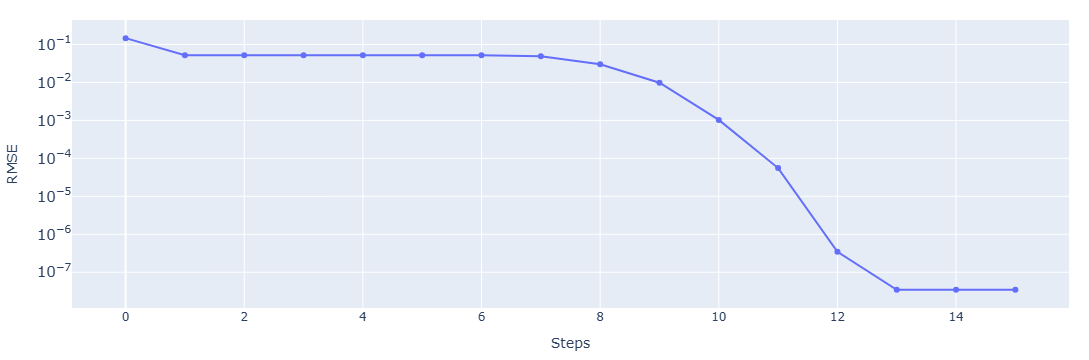

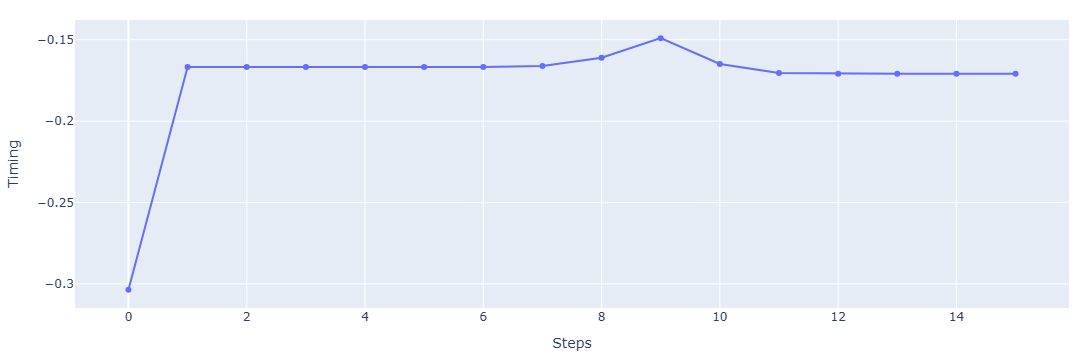

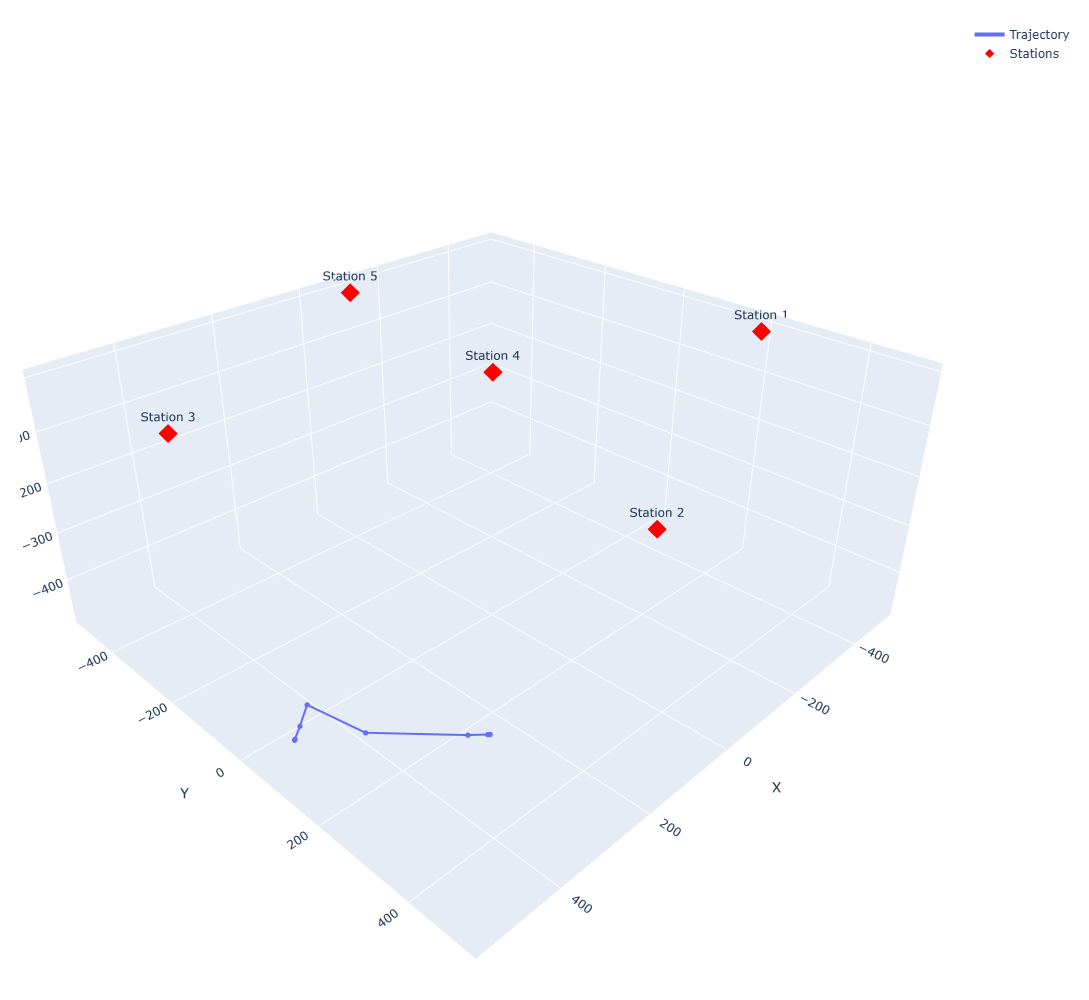

In [5]:
event_best_GN, history_GN, cost_story_GN, misfit_fin_GN = Gauss_Newton.Gauss_Newton(
    stations=stations_norm,
    event_test=np.copy(event_ini),
    n_iteration=1_000,
    steps=np.array([1.0, 1.0, 1.0, 0.0005]),
    vp=vp)

print('Best fitt with:')
print(f'\t- RMSE = {misfit_fin_GN}')
print(f'\t- Event = {event_best_GN}')

Results['Gauss-Newton'] = {'X':event_best_GN['X'],
                           'Y':event_best_GN['Y'],
                           'Z':event_best_GN['Z'],
                           't':event_best_GN['t'],
                           'RMSE':misfit_fin_GN}

_ = graphics.history_2d(cost_story_GN, 'RMSE', log_y=True, filename=None)
_ = graphics.history_2d(history_GN[:, 3], 'Timing', filename=None)
_ = graphics.history_3d(history_GN[:, :3], stations_norm, filename=None)

Best fitt with:
	- RMSE = 3.437276544239551e-08
	- Event = {'X': 486.07078570679283, 'Y': 36.672708947753144, 'Z': -479.20534686473195, 't': -0.17088876779229695}


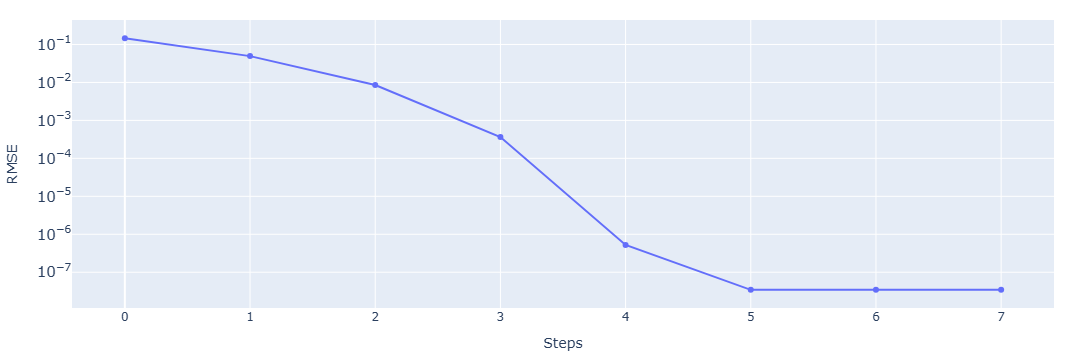

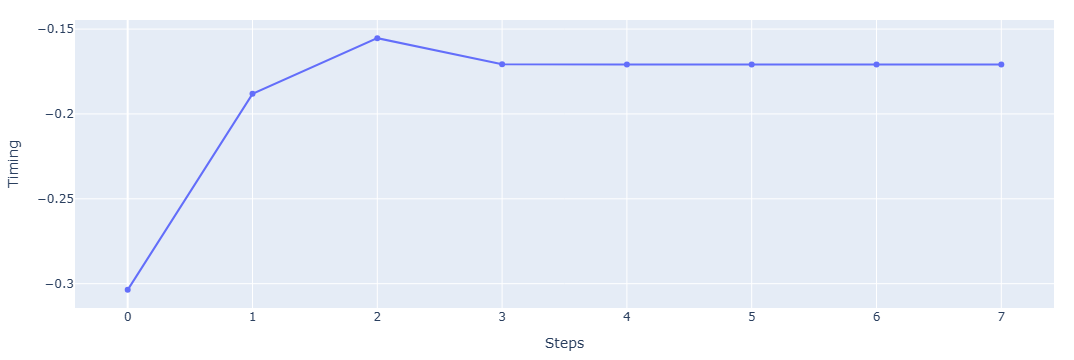

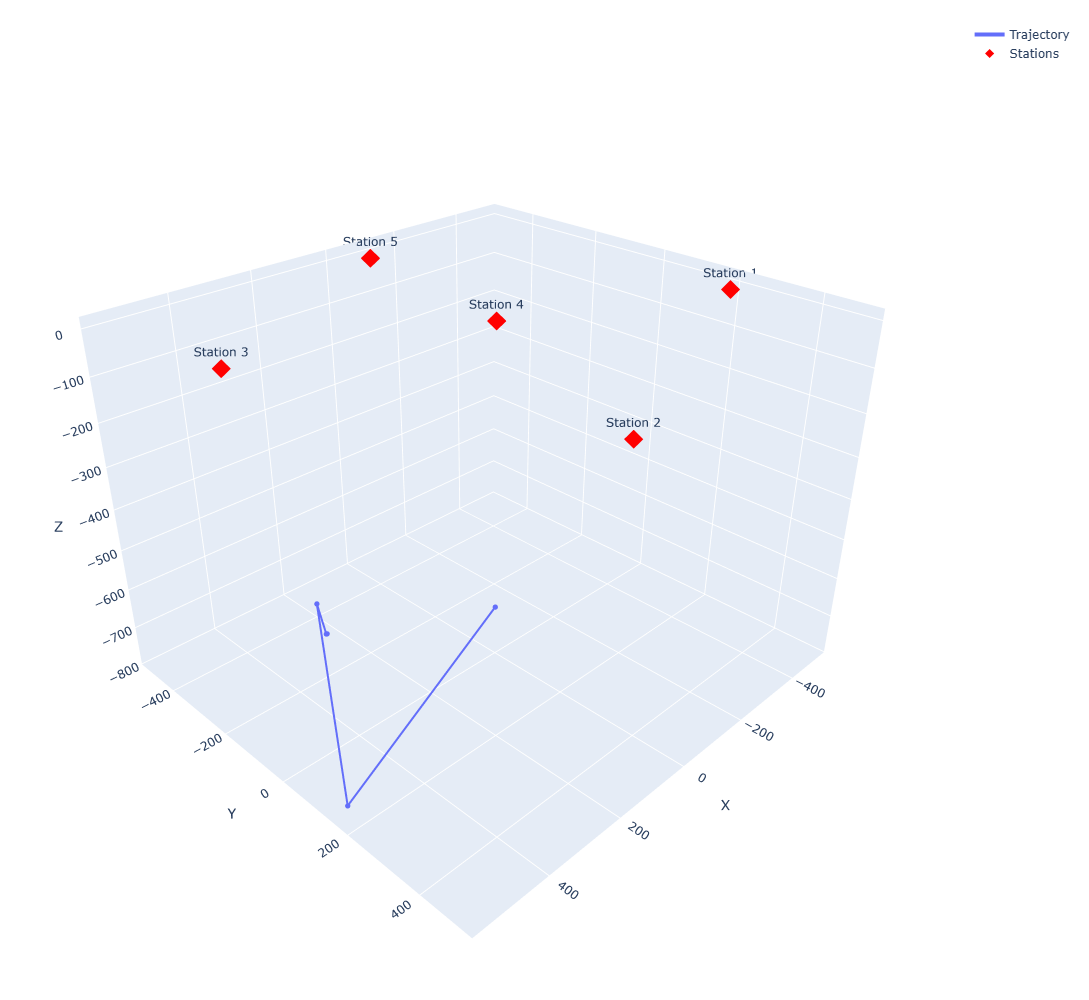

In [6]:
event_best_LM, history_LM, cost_story_LM, misfit_fin_LM = Levenberg_Marquardt.Levenberg_Marquardt(
    stations=stations_norm,
    event_test=np.copy(event_ini),
    n_iteration=1_000,
    vp=vp)

print('Best fitt with:')
print(f'\t- RMSE = {misfit_fin_LM}')
print(f'\t- Event = {event_best_LM}')

Results['Levenberg-Marquardt'] = {'X':event_best_LM['X'],
                                  'Y':event_best_LM['Y'],
                                  'Z':event_best_LM['Z'],
                                  't':event_best_LM['t'],
                                  'RMSE':misfit_fin_LM}

_ = graphics.history_2d(cost_story_LM, 'RMSE', log_y=True, filename=None)
_ = graphics.history_2d(history_LM[:, 3], 'Timing', filename=None)
_ = graphics.history_3d(history_LM[:, :3], stations_norm, filename=None)

Best fitt with:
	- RMSE = 3.4372774548376337e-08
	- Event = {'X': 486.07078628603915, 'Y': 36.672708939410256, 'Z': -479.2053481116988, 't': -0.17088876806612005}


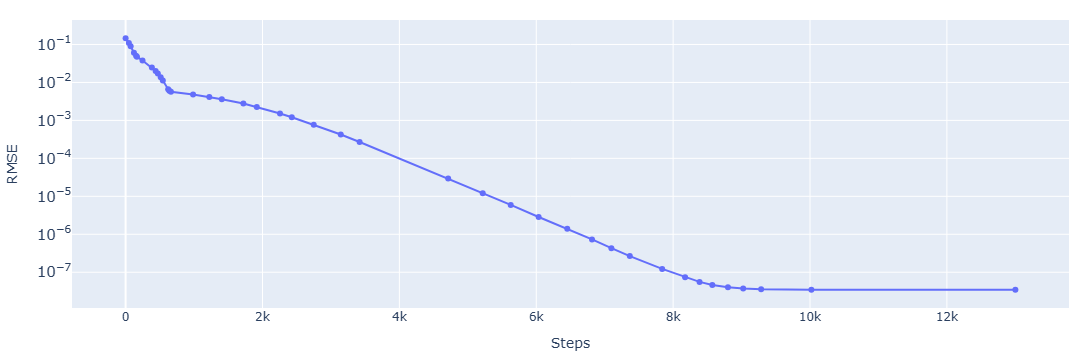

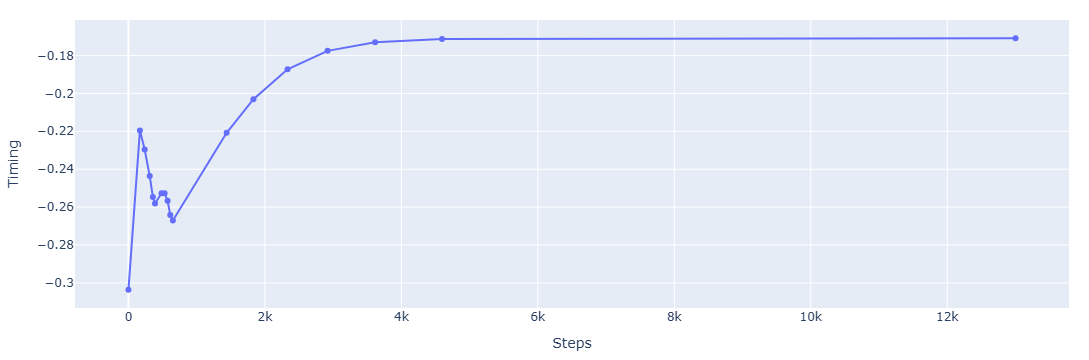

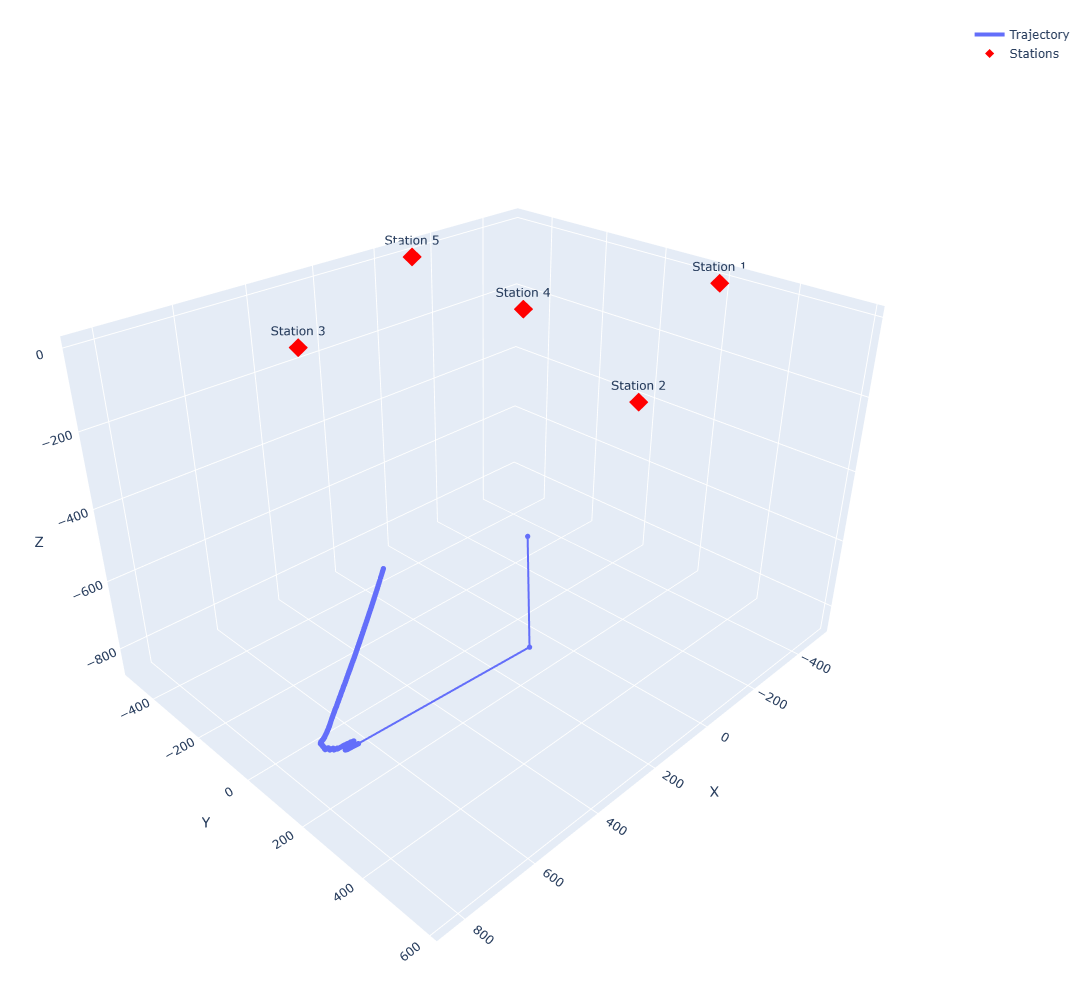

In [7]:
event_best_US, history_US, cost_story_US, misfit_fin_US = Uniq_searcher.gradient_descent(
    stations=stations_norm,
    event_test=np.copy(event_ini),
    n_iteration=200_000,
    steps=np.array([1.0, 1.0, 1.0, 0.0005]),
    lr_decay=0.05,
    patience=500,
    vp=4000.0)

print('Best fitt with:')
print(f'\t- RMSE = {misfit_fin_US}')
print(f'\t- Event = {event_best_US}')

Results['Unique searcher'] = {'X':event_best_US['X'],
                              'Y':event_best_US['Y'],
                              'Z':event_best_US['Z'],
                              't':event_best_US['t'],
                              'RMSE':misfit_fin_US}

_ = graphics.history_2d(cost_story_US, 'RMSE', log_y=True, filename=None)
_ = graphics.history_2d(history_US[:, 3], 'Timing', filename=None)
_ = graphics.history_3d(history_US[:, :3], stations_norm, filename=None)

Best fitt with:
	- RMSE = 3.4532499921477374e-08
	- Event = {'X': 486.0707702636719, 'Y': 36.672733306884766, 'Z': -479.2053527832031, 't': -0.1708887666463852}


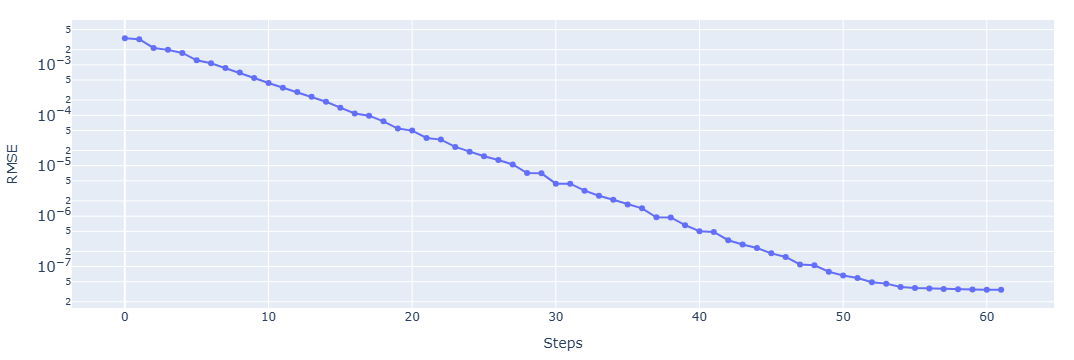

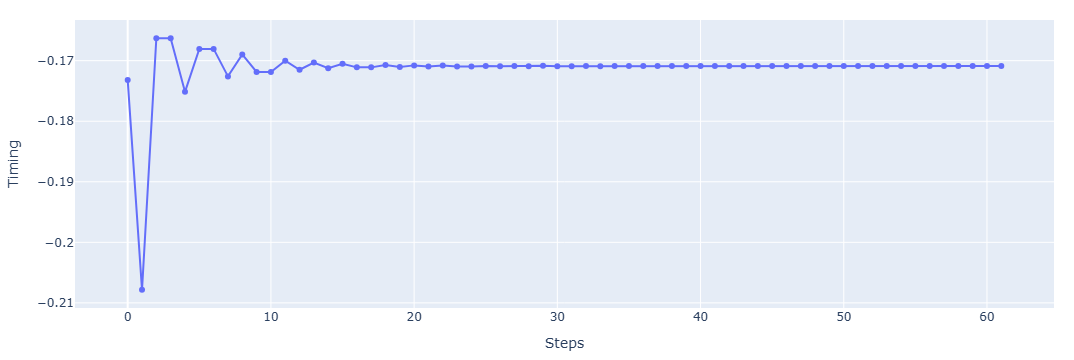

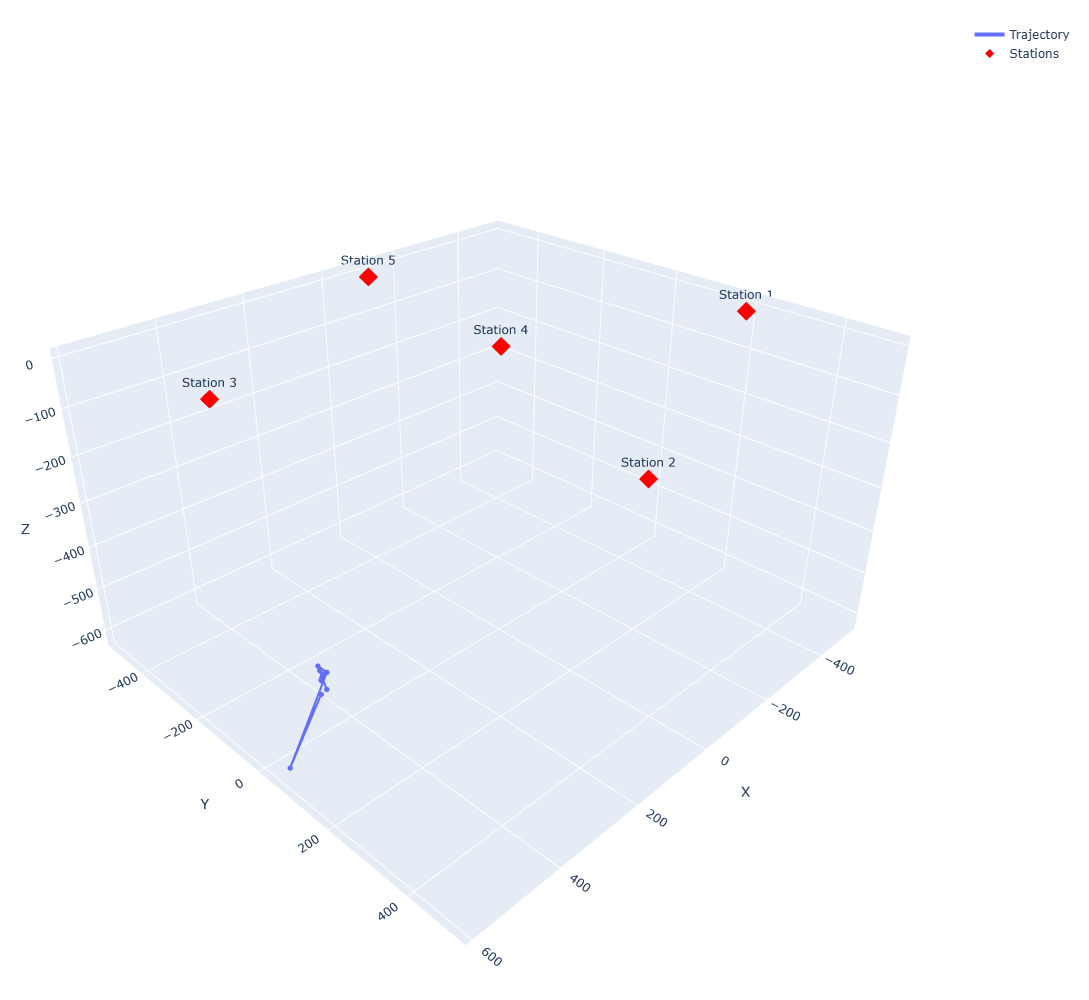

In [8]:
event_best_DG, history_DG, cost_story_DG, misfit_fin_DG = deepening_grid.deepening_grid_search(
    stations=stations_norm,
    sampling_f=21,
    limites=np.copy(limites),
    depth=10001,
    halving_rate=0.20,
    vp=4000.0)

print('Best fitt with:')
print(f'\t- RMSE = {misfit_fin_DG}')
print(f'\t- Event = {event_best_DG}')

Results['Deepening grid'] = {'X':event_best_DG['X'],
                             'Y':event_best_DG['Y'],
                             'Z':event_best_DG['Z'],
                             't':event_best_DG['t'],
                             'RMSE':misfit_fin_DG}

_ = graphics.history_2d(cost_story_DG, 'RMSE', log_y=True, filename=None)
_ = graphics.history_2d(history_DG[:, 3], 'Timing', filename=None)
_ = graphics.history_3d(history_DG[:, :3], stations_norm, filename=None)

Best fitt with:
	- RMSE = 3.775557768184607e-08
	- Event = {'X': 486.07049560546875, 'Y': 36.67267608642578, 'Z': -479.2049560546875, 't': -0.17088867723941803}


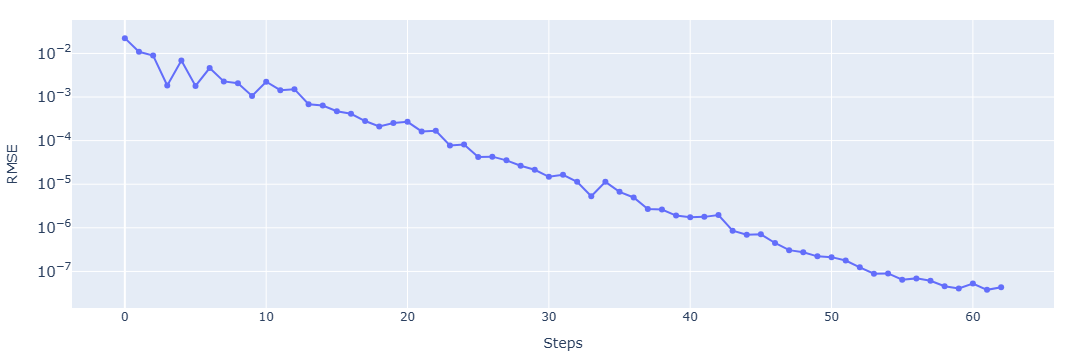

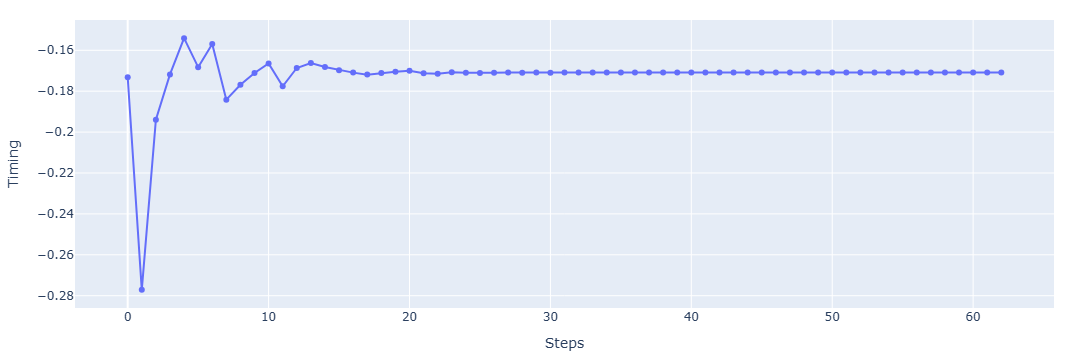

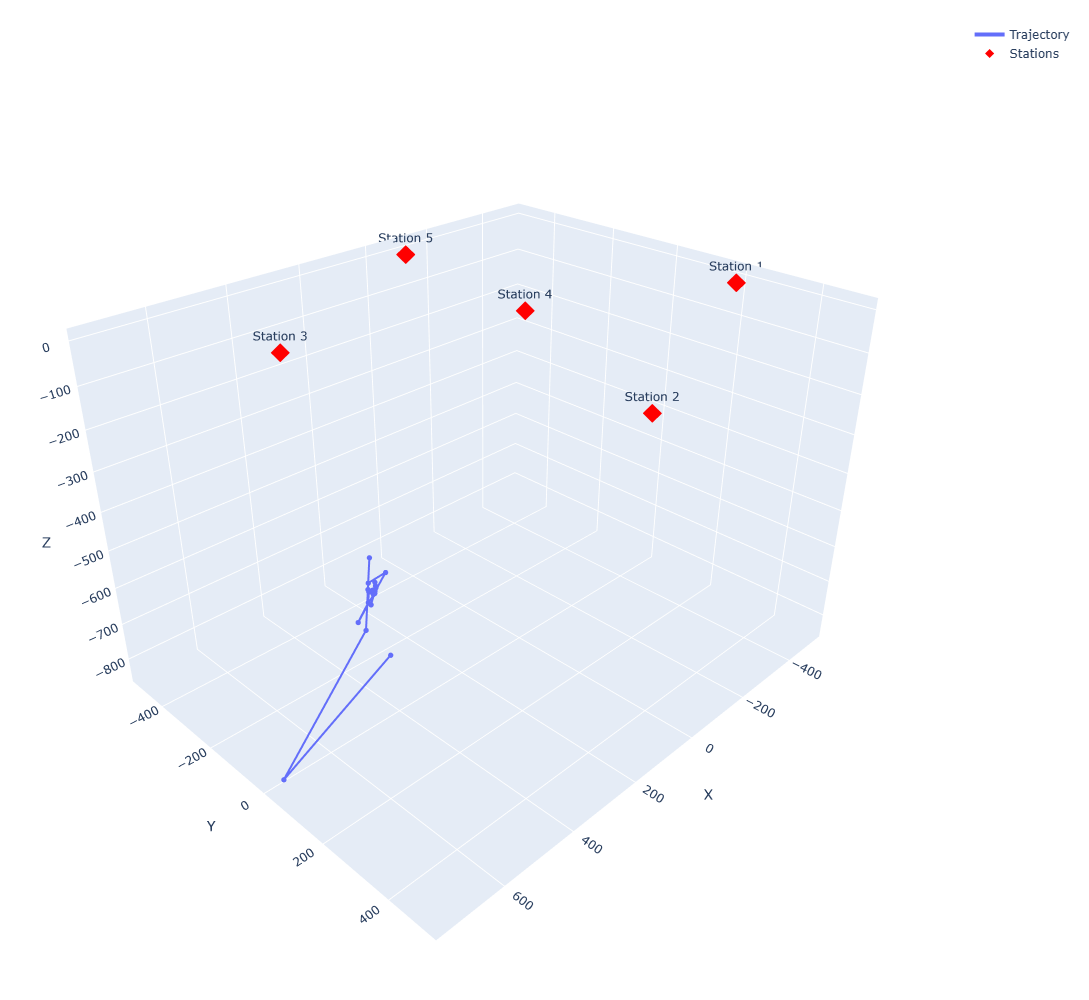

In [9]:
event_best_DS, history_DS, cost_story_DS, misfit_fin_DS = deepening_grid.deepening_grid_sampling(
    stations=stations_norm,
    sampling_f=6,
    limites=np.copy(limites),
    depth=1001,
    halving_rate=0.20,
    n_samples=100,
    vp=4000.0)

print('Best fitt with:')
print(f'\t- RMSE = {misfit_fin_DS}')
print(f'\t- Event = {event_best_DS}')

Results['Deepening sampling'] = {'X':event_best_DS['X'],
                                 'Y':event_best_DS['Y'],
                                 'Z':event_best_DS['Z'],
                                 't':event_best_DS['t'],
                                 'RMSE':misfit_fin_DS}

_ = graphics.history_2d(cost_story_DS, 'RMSE', log_y=True, filename=None)
_ = graphics.history_2d(history_DS[:, 3], 'Timing', filename=None)
_ = graphics.history_3d(history_DS[:, :3], stations_norm, filename=None)

Best fitt with:
	- RMSE = 0.0012776468647643924
	- Event = {'X': 494.8593444824219, 'Y': 37.542701721191406, 'Z': -466.238037109375, 't': -0.17054297029972076}


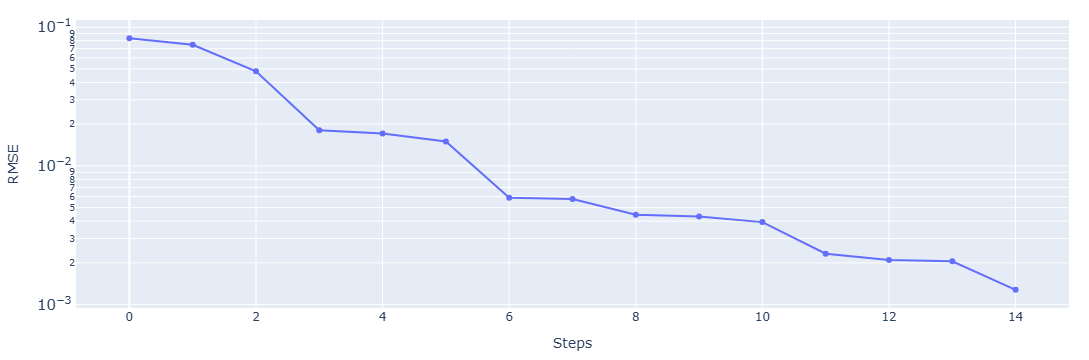

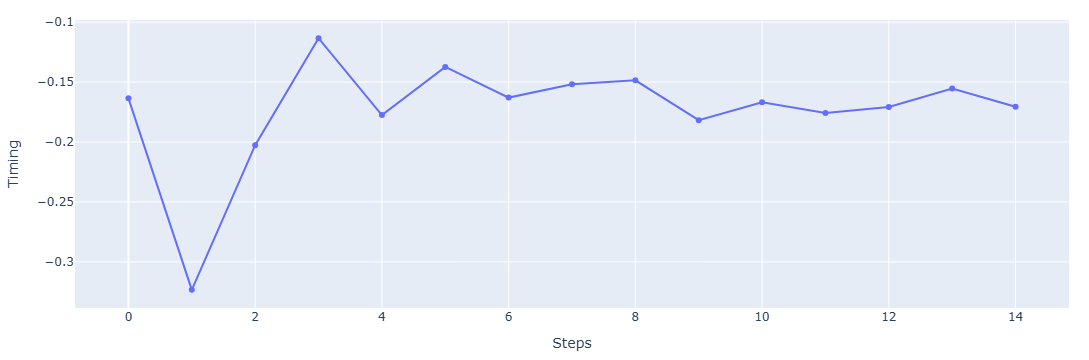

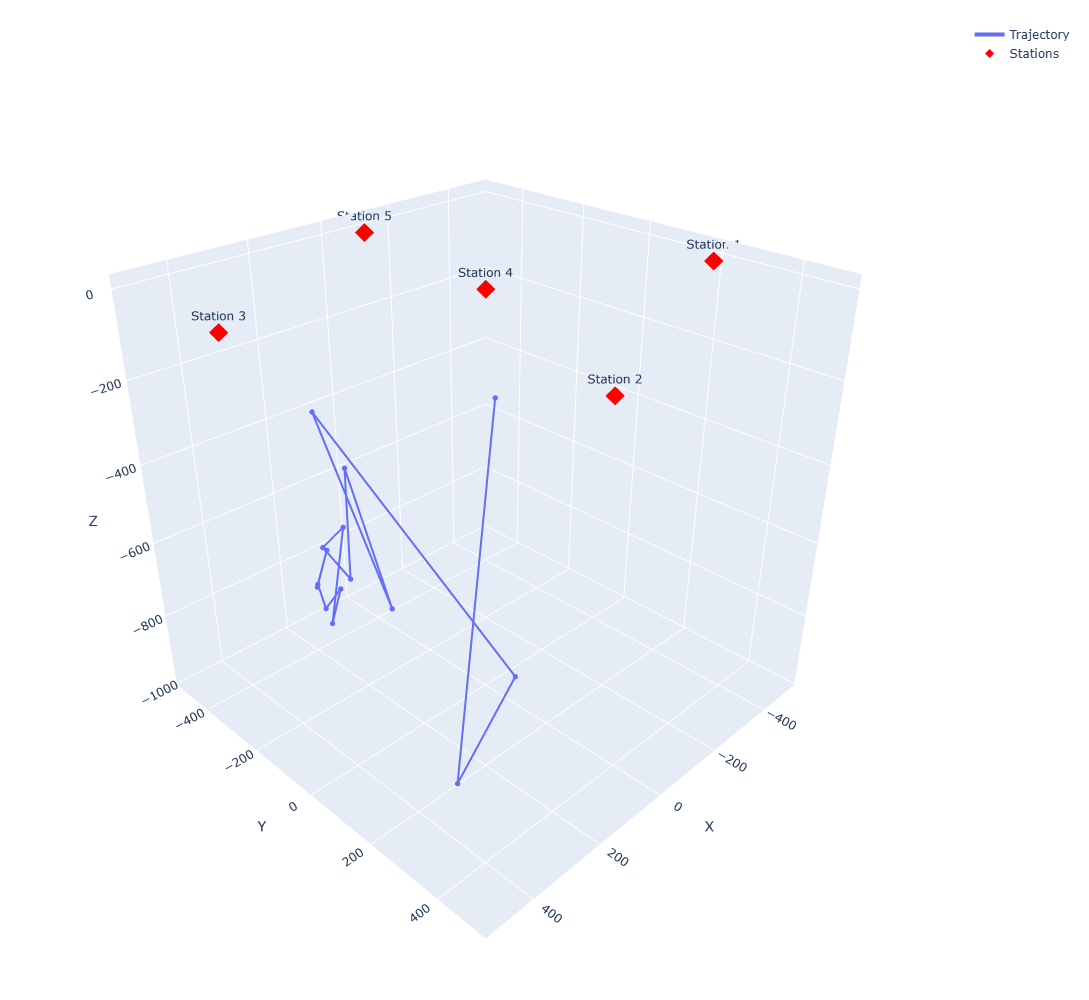

In [10]:
event_best_Mu, history_Mu, cost_story_Mu, misfit_fin_Mu = monte_carlo.monte_carlo(
    stations=stations_norm,
    limites=np.copy(limites),
    n_samples=10_000_000,
    sampling='uniform',
    vp=4000.0)

print('Best fitt with:')
print(f'\t- RMSE = {misfit_fin_Mu}')
print(f'\t- Event = {event_best_Mu}')

Results['Monte-Carlo uniform'] = {'X':event_best_Mu['X'],
                                  'Y':event_best_Mu['Y'],
                                  'Z':event_best_Mu['Z'],
                                  't':event_best_Mu['t'],
                                  'RMSE':misfit_fin_Mu}

_ = graphics.history_2d(cost_story_Mu, 'RMSE', log_y=True, filename=None)
_ = graphics.history_2d(history_Mu[:, 3], 'Timing', filename=None)
_ = graphics.history_3d(history_Mu[:, :3], stations_norm, filename=None)

Best fitt with:
	- RMSE = 0.0008881880203261971
	- Event = {'X': 486.699951171875, 'Y': 38.04493713378906, 'Z': -496.905517578125, 't': -0.17436428368091583}


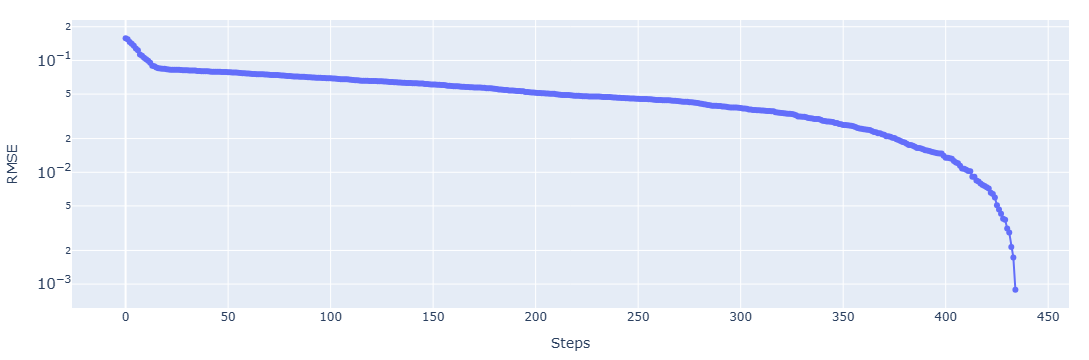

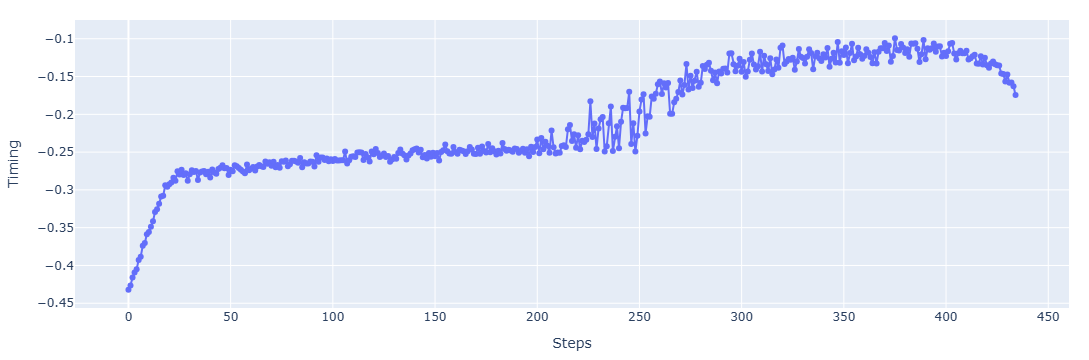

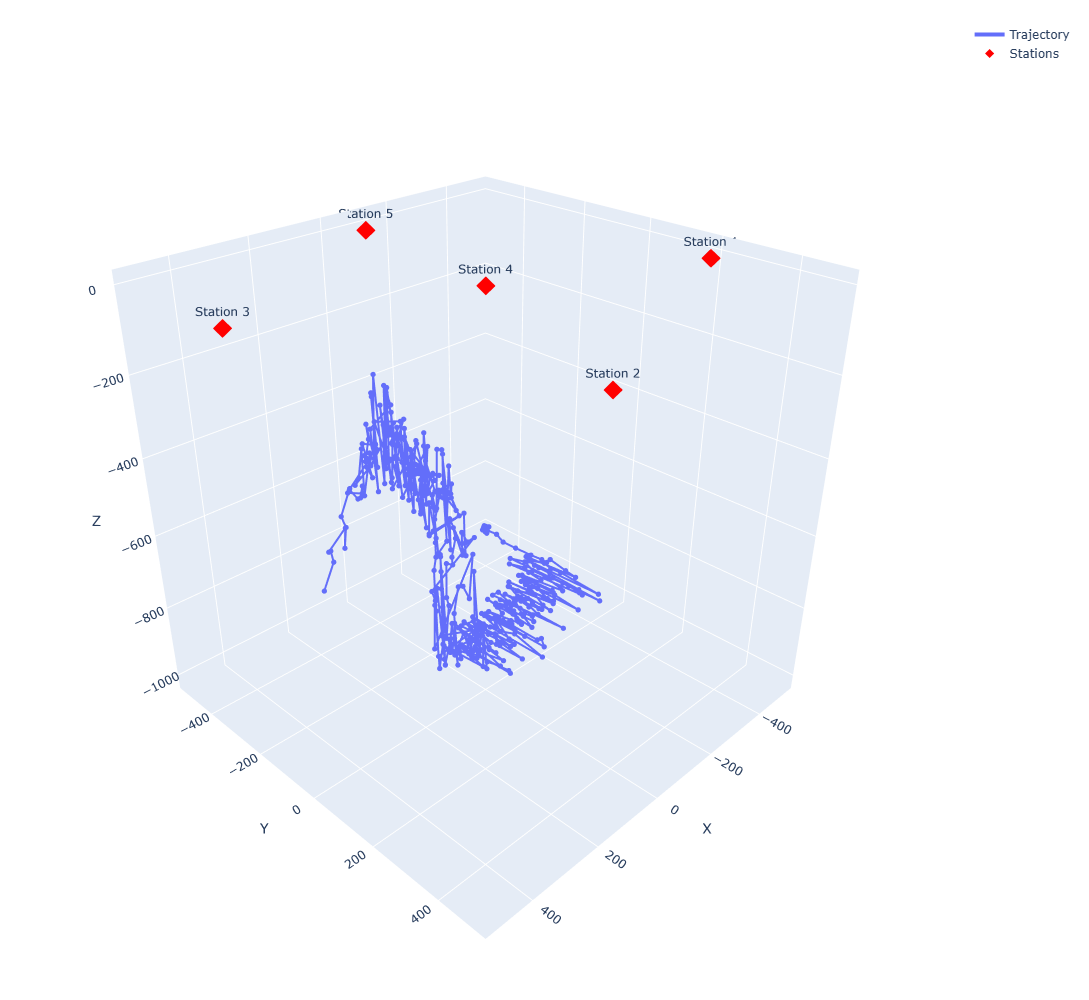

In [11]:
event_best_Mg, history_Mg, cost_story_Mg, misfit_fin_Mg = monte_carlo.monte_carlo(
    stations=stations_norm,
    limites=np.copy(limites),
    n_samples=10_000_000,
    sampling='grid_rand',
    vp=4000.0)

print('Best fitt with:')
print(f'\t- RMSE = {misfit_fin_Mg}')
print(f'\t- Event = {event_best_Mg}')

Results['Monte-Carlo r grid'] = {'X':event_best_Mg['X'],
                                 'Y':event_best_Mg['Y'],
                                 'Z':event_best_Mg['Z'],
                                 't':event_best_Mg['t'],
                                 'RMSE':misfit_fin_Mg}

_ = graphics.history_2d(cost_story_Mg, 'RMSE', log_y=True, filename=None)
_ = graphics.history_2d(history_Mg[:, 3], 'Timing', filename=None)
_ = graphics.history_3d(history_Mg[:, :3], stations_norm, filename=None)

Best fitt with:
	- RMSE = 0.0011914452770724893
	- Event = {'X': 483.8830871582031, 'Y': 44.212730407714844, 'Z': -484.9600830078125, 't': -0.17231449484825134}


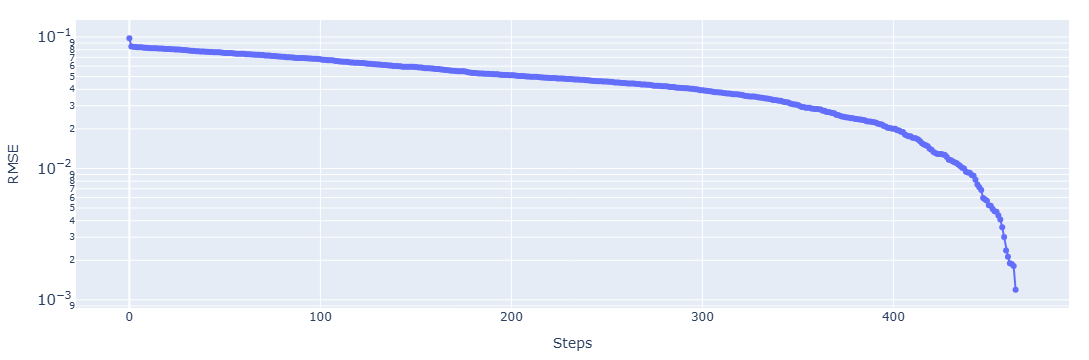

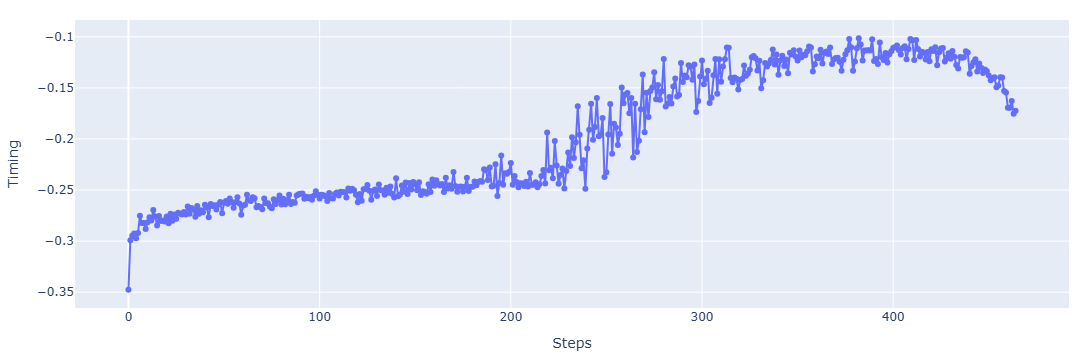

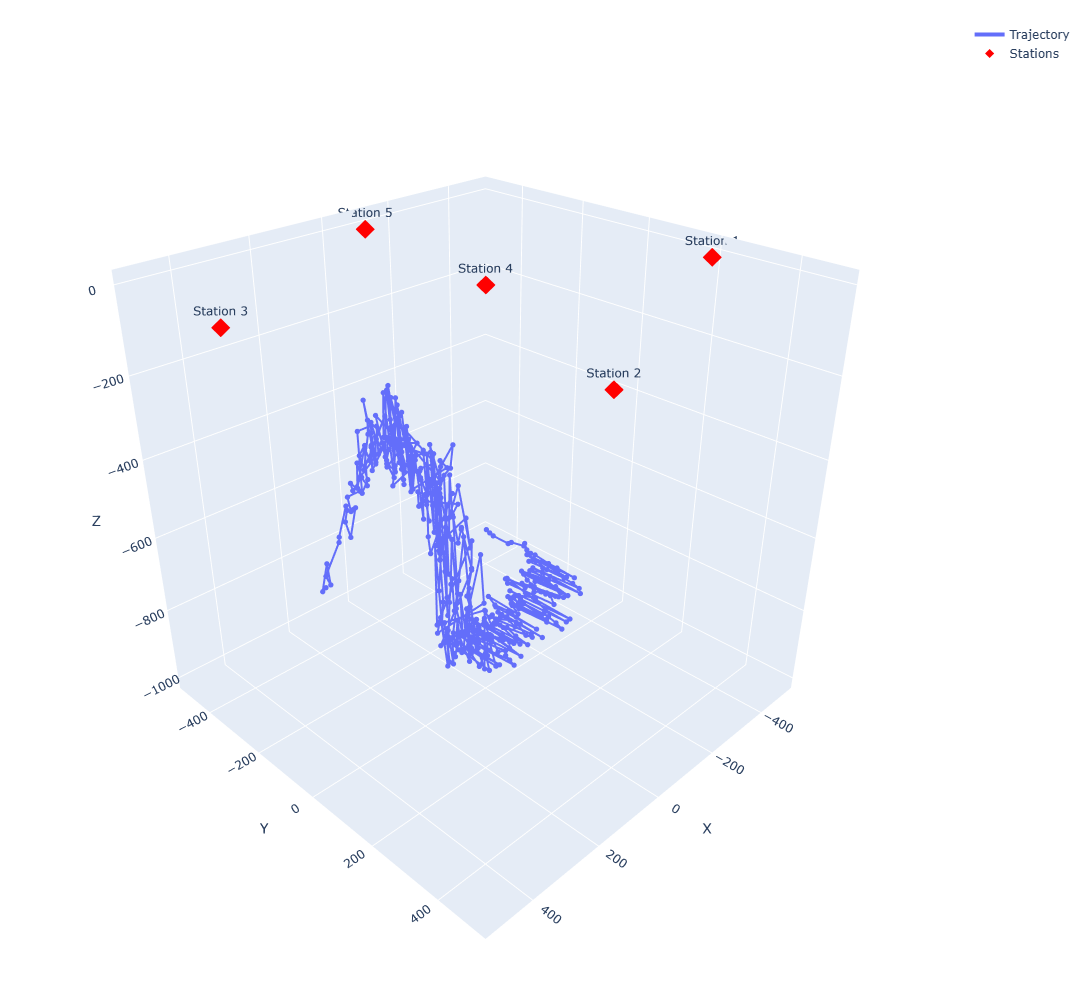

In [12]:
event_best_Mf, history_Mf, cost_story_Mf, misfit_fin_Mf = monte_carlo.monte_carlo(
    stations=stations_norm,
    limites=np.copy(limites),
    n_samples=10_000_000,
    sampling='fcc',
    vp=4000.0)

print('Best fitt with:')
print(f'\t- RMSE = {misfit_fin_Mf}')
print(f'\t- Event = {event_best_Mf}')

Results['Monte-Carlo fcc sampling'] = {'X':event_best_Mf['X'],
                                       'Y':event_best_Mf['Y'],
                                       'Z':event_best_Mf['Z'],
                                       't':event_best_Mf['t'],
                                       'RMSE':misfit_fin_Mf}

_ = graphics.history_2d(cost_story_Mf, 'RMSE', log_y=True, filename=None)
_ = graphics.history_2d(history_Mf[:, 3], 'Timing', filename=None)
_ = graphics.history_3d(history_Mf[:, :3], stations_norm, filename=None)

Best fitt with:
	- RMSE = 3.4372769791074075e-08
	- Event = {'X': 486.0707860810359, 'Y': 36.6727089809872, 'Z': -479.2053476766061, 't': -0.17088876796606003}


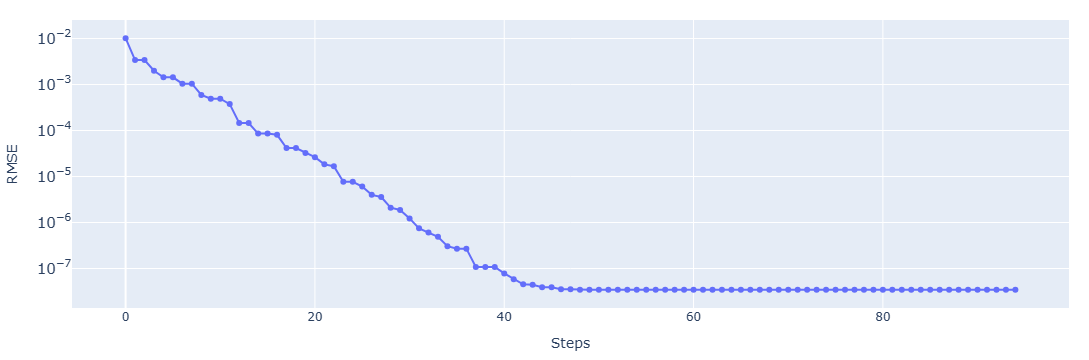

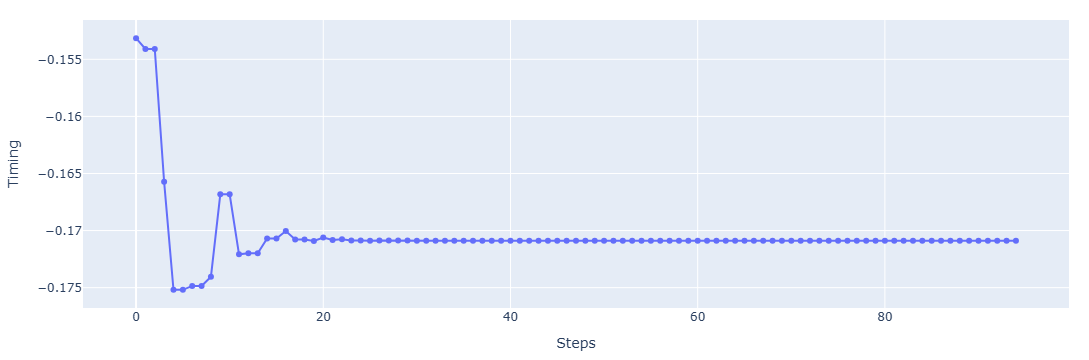

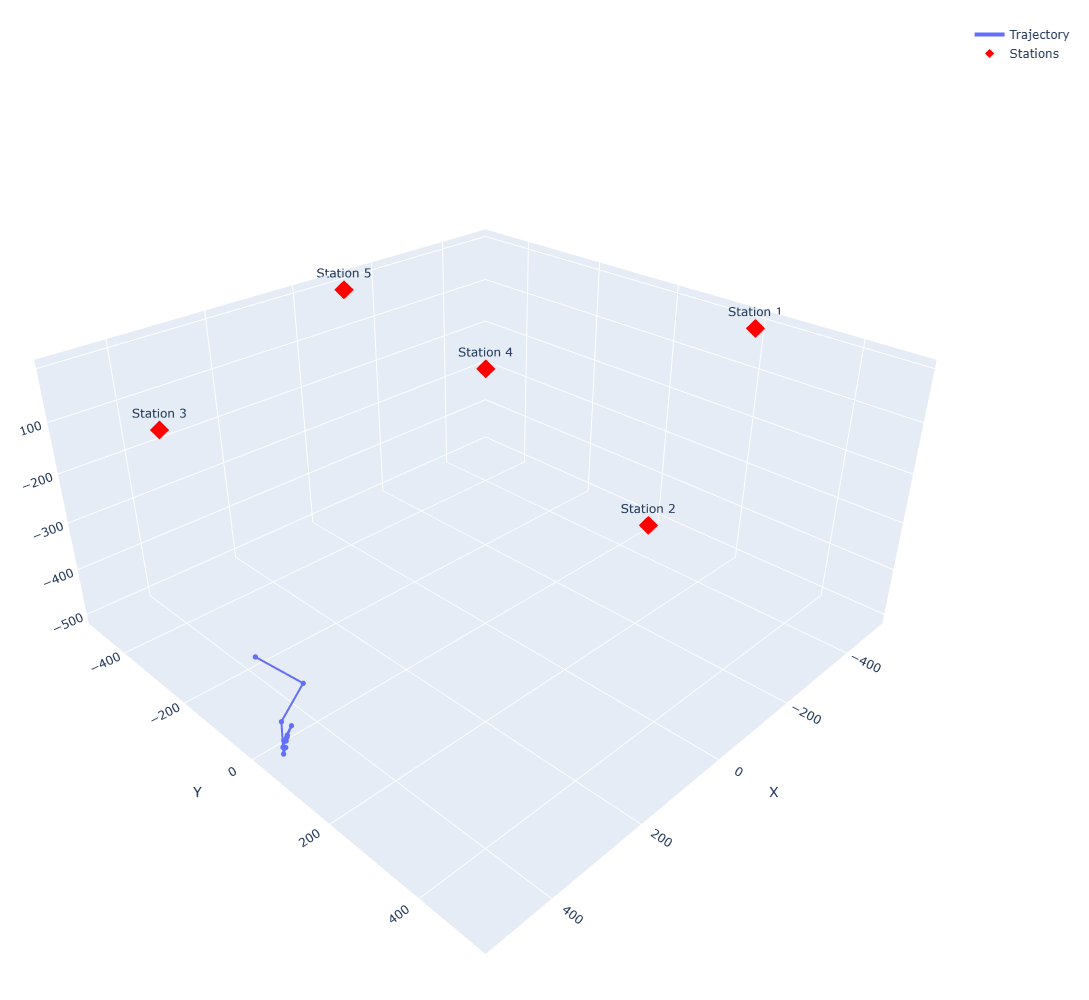

In [13]:
event_best_EV, history_EV, cost_story_EV, misfit_fin_EV = Evolutionary.evolution(
    pop_size=10_000,
    limites=np.copy(limites),
    n_iteration=1_000,
    stations=stations_norm,
    p_surv=0.10,
    patience=10,
    vp=4000.0)

print('Best fitt with:')
print(f'\t- RMSE = {misfit_fin_EV}')
print(f'\t- Event = {event_best_EV}')

Results['Evolutionary'] = {'X':event_best_EV['X'],
                           'Y':event_best_EV['Y'],
                           'Z':event_best_EV['Z'],
                           't':event_best_EV['t'],
                           'RMSE':misfit_fin_EV}

_ = graphics.history_2d(cost_story_EV, 'RMSE', log_y=True, filename=None)
_ = graphics.history_2d(history_EV[:, 3], 'Timing', filename=None)
_ = graphics.history_3d(history_EV[:, :3], stations_norm, filename=None)

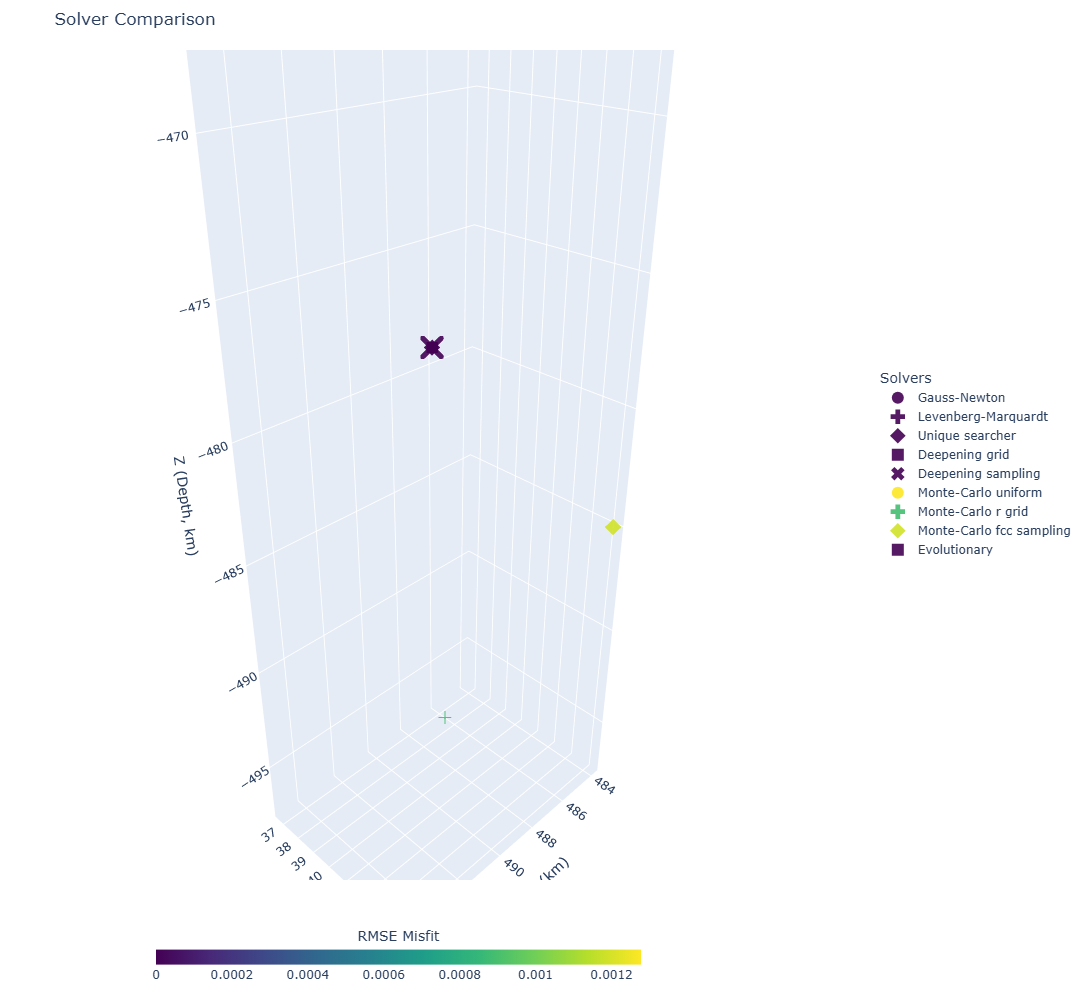

In [14]:
# Making some comparison
_ = graphics.solver_compare(Results,
                            None,
                            None,
                            title="Solver Comparison",
                            colorscale="Viridis",
                            filename=None,
                            height=1000)

In [15]:
_ = graphics.build_tables(Results, rounding=12)

+--------------------------+------------------+-----------------+-------------------+-----------------+---------------+
|          Models          |        X         |        Y        |         Z         |        t        | RMSE (*10^-3) |
+--------------------------+------------------+-----------------+-------------------+-----------------+---------------+
|       Gauss-Newton       | 486.070785706793 | 36.672708947753 | -479.205346864732 | -0.170888767792 |   3.44e-05    |
+--------------------------+------------------+-----------------+-------------------+-----------------+---------------+
|   Levenberg-Marquardt    | 486.070785706793 | 36.672708947753 | -479.205346864732 | -0.170888767792 |   3.44e-05    |
+--------------------------+------------------+-----------------+-------------------+-----------------+---------------+
|       Evolutionary       | 486.070786081036 | 36.672708980987 | -479.205347676606 | -0.170888767966 |   3.44e-05    |
+--------------------------+------------